# Finding the Sweet Spot Window Length for L63

## Gradient Quality vs Window Length Analysis

In [2]:
# Setup
import Random
import Pkg
Pkg.activate("../../")
using LorenzParameterEstimation
using LorenzParameterEstimation: L63Parameters, classic_params, integrate, window_rmse, 
                                modular_train!, adamw_config, TrainingMetrics
using Plots, Statistics, LinearAlgebra
Random.seed!(42)

  Activating project at `~/master_thesis/LorenzParameterEstimation`


Random.TaskLocalRNG()

## Sweet Spot Detection

In [28]:
# Sweet spot analysis
function find_gradient_sweet_spot()
    # True system
    true_params = L63Parameters(10.2, 28.0, 8/3)
    u0 = [1.0, 1.0, 1.0]
    T_total = 1000.0
    dt = 0.01
    
    # Generate long reference trajectory
    ref_sol = integrate(true_params, u0, (0.0, T_total), dt)
    
    # Test window lengths (in time units)
    window_times = [0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0, 50.0, 75.0, 100.0, 150.0, 200.0]
    
    results = []
    
    for t_window in window_times
        window_size = Int(round(t_window / dt))
        print("Testing window size: $window_size (time: $t_window)")
        # Quick training to get gradients
        metrics = TrainingMetrics{Float64}()
        result = modular_train!(
            classic_params(),
            ref_sol;
            optimizer_config = adamw_config(learning_rate=1e-3),
            loss_function = window_rmse,
            epochs = 50,
            window_size = window_size,
            stride = window_size ÷ 2,
            batch_size = 8,
            update_σ = true,
            update_ρ = false,
            update_β = false,
            verbose = false,
            track_gradients = true,
            metrics = metrics
        )
        
        # Analyze gradient quality
        grads = metrics.individual_gradients_σ
        
        if !isempty(grads)
            grad_mean = mean(abs.(grads))
            grad_std = std(grads)
            grad_snr = grad_mean / max(grad_std, 1e-12)
            final_error = abs(result.best_params.σ - true_params.σ)
            convergence_rate = (result.train_loss[1] - result.train_loss[end]) / result.train_loss[1]
        else
            grad_mean = grad_std = grad_snr = final_error = convergence_rate = 0.0
        end
        
        push!(results, (
            window_time = t_window,
            window_size = window_size,
            grad_mean = grad_mean,
            grad_std = grad_std,
            grad_snr = grad_snr,
            final_error = final_error,
            convergence_rate = convergence_rate
        ))
    end
    
    return results
end

sweet_spot_results = find_gradient_sweet_spot()

Testing window size: 10 (time: 0.1)Testing window size: 20 (time: 0.2)Testing window size: 50 (time: 0.5)Testing window size: 100 (time: 1.0)Testing window size: 150 (time: 1.5)Testing window size: 200 (time: 2.0)Testing window size: 300 (time: 3.0)Testing window size: 500 (time: 5.0)Testing window size: 700 (time: 7.0)Testing window size: 1000 (time: 10.0)Testing window size: 1500 (time: 15.0)Testing window size: 2000 (time: 20.0)Testing window size: 3000 (time: 30.0)Testing window size: 5000 (time: 50.0)Testing window size: 7500 (time: 75.0)Testing window size: 10000 (time: 100.0)Testing window size: 15000 (time: 150.0)Testing window size: 20000 (time: 200.0)

18-element Vector{Any}:
 (window_time = 0.1, window_size = 10, grad_mean = 0.02062677350355233, grad_std = 0.029866701922788237, grad_snr = 0.6906277618759821, final_error = 0.16486722428529887, convergence_rate = -22.41903783709467)
 (window_time = 0.2, window_size = 20, grad_mean = 0.06054081891982032, grad_std = 0.08102837216002405, grad_snr = 0.7471558085883475, final_error = 0.1582470579524191, convergence_rate = -28.071365726519517)
 (window_time = 0.5, window_size = 50, grad_mean = 0.16514812706402476, grad_std = 0.22498611027858895, grad_snr = 0.7340369894813958, final_error = 0.0541655788608022, convergence_rate = -22.53171274063338)
 (window_time = 1.0, window_size = 100, grad_mean = 0.43352020996929286, grad_std = 0.859155732921829, grad_snr = 0.5045886250388752, final_error = 0.07900564891359885, convergence_rate = -15.49018249964111)
 (window_time = 1.5, window_size = 150, grad_mean = 0.7360126290692979, grad_std = 2.666413868343794, grad_snr = 0.2760309034570323, final_er

## Results Analysis

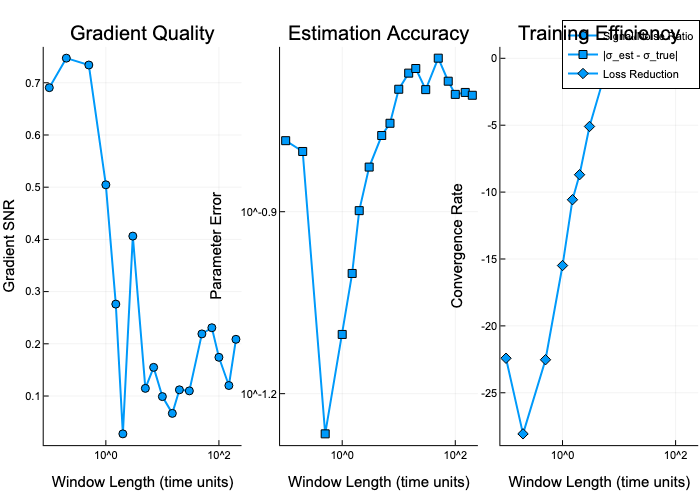

In [31]:
# Plot results with interactive hover information
plotlyjs()

function plot_sweet_spot_analysis(results)
    window_times = [r.window_time for r in results]
    window_sizes = [r.window_size for r in results]
    grad_snrs = [r.grad_snr for r in results]
    final_errors = [r.final_error for r in results]
    convergence_rates = [r.convergence_rate for r in results]

    # Build hover text for each metric so we can surface raw values on hover
    grad_hover = ["Window: $(round(window_times[i], sigdigits=4)) time units<br>Steps: $(window_sizes[i])<br>Gradient SNR: $(round(grad_snrs[i], sigdigits=4))"
                  for i in eachindex(window_times)]
    error_hover = ["Window: $(round(window_times[i], sigdigits=4)) time units<br>Steps: $(window_sizes[i])<br>Parameter Error: $(round(final_errors[i], sigdigits=4))"
                   for i in eachindex(window_times)]
    convergence_hover = ["Window: $(round(window_times[i], sigdigits=4)) time units<br>Steps: $(window_sizes[i])<br>Convergence Rate: $(round(convergence_rates[i], sigdigits=4))"
                         for i in eachindex(window_times)]

    p1 = plot(window_times, grad_snrs,
              xlabel="Window Length (time units)", ylabel="Gradient SNR",
              title="Gradient Quality", marker=:circle, linewidth=2,
              xscale=:log10, label="Signal/Noise Ratio",
              hover=grad_hover)

    p2 = plot(window_times, final_errors,
              xlabel="Window Length (time units)", ylabel="Parameter Error",
              title="Estimation Accuracy", marker=:square, linewidth=2,
              xscale=:log10, yscale=:log10, label="|σ_est - σ_true|",
              hover=error_hover)

    p3 = plot(window_times, convergence_rates,
              xlabel="Window Length (time units)", ylabel="Convergence Rate",
              title="Training Efficiency", marker=:diamond, linewidth=2,
              xscale=:log10, label="Loss Reduction",
              hover=convergence_hover)

    plot(p1, p2, p3, layout=(1,3), size=(1500, 400))
end

plot_sweet_spot_analysis(sweet_spot_results)



## Numerical Results

In [24]:
# Print detailed results
function print_sweet_spot_table(results)
    println("Window Length | Grad SNR | Param Error | Convergence")
    println("-" ^ 50)
    
    for r in results
        println("$(rpad(r.window_time, 12)) | $(rpad(round(r.grad_snr, digits=2), 8)) | $(rpad(round(r.final_error, digits=4), 11)) | $(round(r.convergence_rate, digits=3))")
    end
    
    # Find optimal window
    best_idx = argmax([r.grad_snr * r.convergence_rate / max(r.final_error, 1e-6) for r in results])
    optimal = results[best_idx]
    
    println("\n🎯 Optimal Window Length: $(optimal.window_time) time units")
    println("   Window Size: $(optimal.window_size) steps")
    println("   Gradient SNR: $(round(optimal.grad_snr, digits=2))")
    println("   Parameter Error: $(round(optimal.final_error, digits=4))")
end

print_sweet_spot_table(sweet_spot_results)

Window Length | Grad SNR | Param Error | Convergence
--------------------------------------------------
0.1          | 0.69     | 0.1693      | -22.617
0.2          | 0.75     | 0.1612      | -28.029
0.5          | 0.74     | 0.0634      | -23.088
1.0          | 0.47     | 0.0843      | -15.736
1.5          | 0.37     | 0.1005      | -10.468
2.0          | 0.31     | 0.1369      | -7.469
3.0          | 0.42     | 0.1474      | -5.484
5.0          | 0.16     | 0.1675      | -2.03
7.0          | 0.15     | 0.1791      | -0.579
10.0         | 0.2      | 0.2129      | -0.172
15.0         | 0.16     | 0.2044      | -0.053
20.0         | 0.16     | 0.194       | -0.047
30.0         | 0.1      | 0.1905      | -0.023
50.0         | 0.17     | 0.199       | 0.001
75.0         | 0.19     | 0.1935      | -0.009
100.0        | 0.15     | 0.205       | -0.007
150.0        | 0.22     | 0.1929      | 0.012
200.0        | 0.1      | 0.2133      | -0.019

🎯 Optimal Window Length: 150.0 time units
   Wi

## Ensemble Validation

In [25]:
# Validate with ensemble
function validate_optimal_window(optimal_window_time, n_ensemble=10)
    true_params = L63Parameters(10.3, 28.0, 8/3)
    window_size = Int(round(optimal_window_time / 0.01))
    
    ensemble_results = []
    
    for i in 1:n_ensemble
        # Different initial condition
        u0 = [1.0 + 0.1*randn(), 1.0 + 0.1*randn(), 1.0 + 0.1*randn()]
        ref_sol = integrate(true_params, u0, (0.0, 500.0), 0.01)
        
        result = modular_train!(
            classic_params(),
            ref_sol;
            optimizer_config = adamw_config(learning_rate=1e-3),
            loss_function = window_rmse,
            epochs = 100,
            window_size = window_size,
            stride = window_size ÷ 2,
            batch_size = 8,
            update_σ = true,
            update_ρ = false,
            update_β = false,
            verbose = false
        )
        
        push!(ensemble_results, abs(result.best_params.σ - true_params.σ))
    end
    
    mean_error = mean(ensemble_results)
    std_error = std(ensemble_results)
    
    println("\n🔬 Ensemble Validation (n=$(n_ensemble)):")
    println("   Mean Error: $(round(mean_error, digits=4)) ± $(round(std_error, digits=4))")
    println("   Success Rate: $(count(x -> x < 0.1, ensemble_results))/$(n_ensemble)")
    
    return ensemble_results
end

# Use the optimal window from analysis
optimal_idx = argmax([r.grad_snr * r.convergence_rate / max(r.final_error, 1e-6) for r in sweet_spot_results])
optimal_window = sweet_spot_results[optimal_idx].window_time

ensemble_validation = validate_optimal_window(optimal_window)


🔬 Ensemble Validation (n=10):
   Mean Error: 0.3006 ± 0.0036
   Success Rate: 0/10


10-element Vector{Any}:
 0.29716225991545286
 0.298805980517006
 0.30915613085835325
 0.30070032440922034
 0.30034639497078786
 0.3012640229906225
 0.2974803385293754
 0.2988060370236294
 0.30376448582218885
 0.2981818179785911

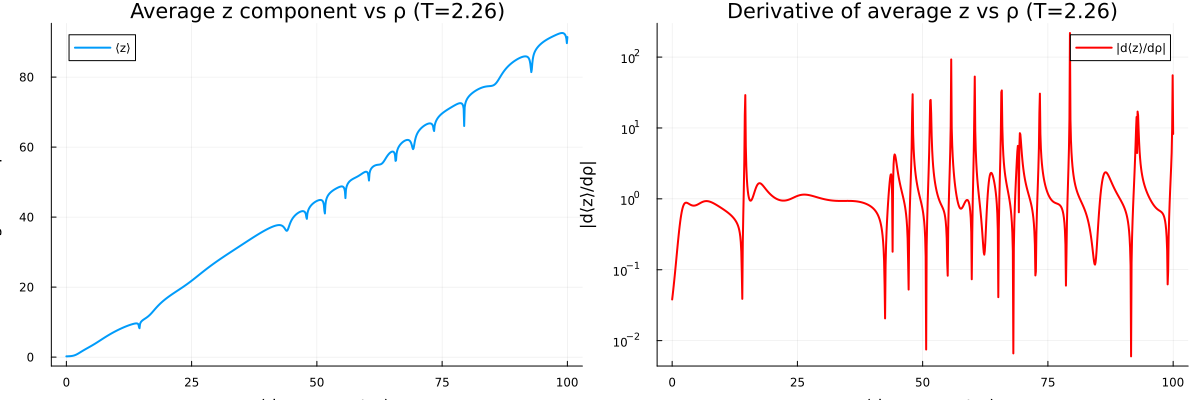

In [26]:
using Enzyme

# Function to compute average z for a given rho
function compute_z_average(ρ, T=2.6, dt=0.005)
    σ = 10.0
    β = 8/3
    u0 = [1.0, 1.0, 1.0]
    
    params = L63Parameters(σ, ρ, β)
    sol = integrate(params, u0, (0.0, T), dt)
    
    # Return average z component
    return mean(sol.u[:, 3])
end

# Function to plot z average and derivative for a given T
function plot_z_avg_and_derivative(T=2.6; dt=0.005, rho_range=0.0:0.1:100.0)
    z_averages = Float64[]
    z_derivatives = Float64[]
    
    for ρ in rho_range
        # Compute average z
        z_avg = compute_z_average(ρ, T, dt)
        push!(z_averages, z_avg)
        
        # Compute derivative using Enzyme
        dz_drho = autodiff(
            Forward,                            # Use Forward mode AD
            ρ -> compute_z_average(ρ, T, dt),   # Function to differentiate 
            Duplicated(ρ, 1.0)                  # Duplicate input for AD
            )[1]
        push!(z_derivatives, dz_drho)
    end
    
    # Plot both average z and its derivative
    p1 = plot(rho_range, z_averages,
             xlabel="ρ (rho parameter)",
             ylabel="Average z component",
             title="Average z component vs ρ (T=$T)",
             linewidth=2,
             label="⟨z⟩",
             grid=true)
    
    p2 = plot(rho_range, abs.(z_derivatives),
             xlabel="ρ (rho parameter)",
             ylabel="|d⟨z⟩/dρ|",
             title="Derivative of average z vs ρ (T=$T)",
             linewidth=2,
             label="|d⟨z⟩/dρ|",
             grid=true,
             color=:red,
             yscale=:log10)
    
    return plot(p1, p2, layout=(1,2), size=(1200, 400))
end

# Example usage
plot_z_avg_and_derivative(2.26)


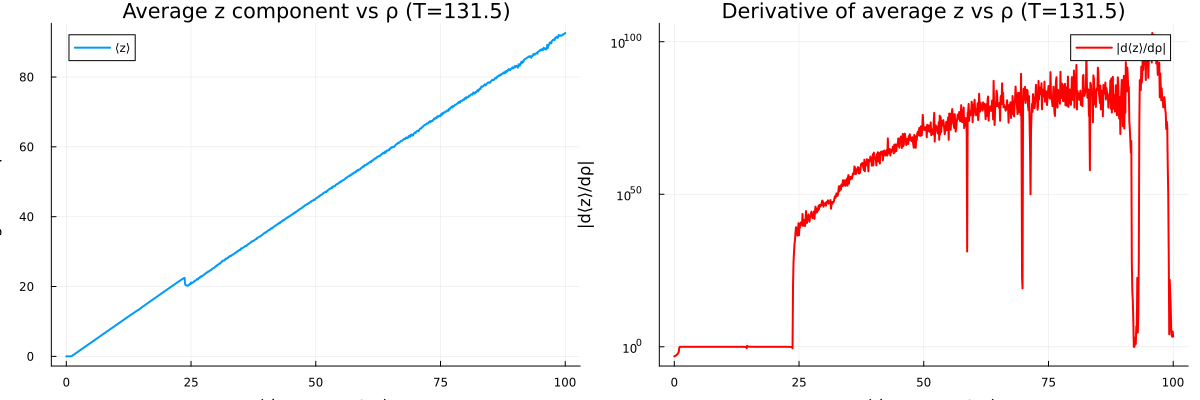

In [27]:
plot_z_avg_and_derivative(131.5)